# UPI Fraud Detection — Model Building

This notebook builds on the engineered features from the previous step. The plan is to train a few models, evaluate them properly, tune the best one, and make it explainable.

Along the way, we'll run a quick statistical check before doing any heavy modeling — partly because it's good practice, and partly because it leads to an important, honest finding about this particular dataset that's worth understanding rather than skipping past.

Here's the full plan:
1. Load the engineered data and pick our features
2. A quick statistical sanity check, before we invest time in modeling
3. Train/test split (carefully, since fraud is rare)
4. Build a proper preprocessing pipeline
5. Train three models: Logistic Regression -> Random Forest -> XGBoost (tuned)
6. Evaluate honestly, and diagnose what we find
7. Run a controlled experiment to confirm our pipeline itself is built correctly
8. Threshold tuning and SHAP explainability on a model that actually has something to explain
9. Save the final model

---

# 1: Setup

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score,
                              average_precision_score, roc_curve, precision_recall_curve,
                              precision_score, recall_score, f1_score)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

COLOR_LEGIT = '#2E86AB'
COLOR_FRAUD = '#E63946'
RANDOM_STATE = 42

print("Ready to go!")

Ready to go!


# 2: Load the Engineered Data

In [82]:
df = pd.read_csv('../data/upi_transactions_features.csv')
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head(3)

Loaded 250,000 rows and 25 columns.


,transaction_id,txn_timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,day_of_week,is_weekend,is_high_amount,amount_log,amount_zscore,is_unusual_amount,is_round_amount,is_night,is_late_night,is_same_bank
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,...,Tuesday,0,0,6.767343,-0.240120,0,0,0,0,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,...,Thursday,0,0,6.919684,-0.162742,0,0,0,0,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,...,Tuesday,0,0,6.169611,-0.451693,0,0,0,0,0


### Choosing Our Features

A few columns are deliberately left out:

- **`transaction_id`** -- a unique label per row, no real pattern to learn from.
- **`txn_timestamp`** -- the raw date/time. We already extracted the useful parts (`hour_of_day`, `day_of_week`, `is_weekend`, `is_night`, `is_late_night`).
- **`amount_inr`** -- we use `amount_log` instead, since we already fixed its skew.
- **`fraud_flag`** -- our target, not a feature.

We're keeping `transaction_status` as a feature, which assumes this model reviews transactions *after* they've gone through (a common setup for batch fraud review) rather than blocking them in real time before completion. Worth remembering: always ask whether a piece of information would actually be available at the moment you need to make a prediction.

In [83]:
numeric_features = ['amount_log', 'amount_zscore', 'hour_of_day']

categorical_features = ['transaction_type', 'merchant_category', 'sender_bank', 'receiver_bank',
                         'sender_state', 'device_type', 'network_type', 'sender_age_group',
                         'receiver_age_group', 'day_of_week', 'transaction_status']

binary_features = ['is_weekend', 'is_high_amount', 'is_unusual_amount',
                    'is_round_amount', 'is_night', 'is_late_night', 'is_same_bank']

feature_columns = numeric_features + categorical_features + binary_features

X = df[feature_columns]
y = df['fraud_flag']

print(f"Using {len(feature_columns)} features to predict fraud_flag.")

Using 21 features to predict fraud_flag.


# 3: A Sanity Check Before We Model Anything

Here before spending time training models, now the first question appear here is -- **does any of our data actually relate to the target at all?** Machine learning models can only find patterns that genuinely exist in the data; they can't invent signal that isn't there.

We'll run two simple statistical tests:
- **Chi-square test** for our categorical/binary features -- checks whether the fraud rate genuinely differs across categories, or whether the differences we saw in the EDA notebook could just be random noise.
- **Point-biserial correlation** for our numeric features -- a correlation measure built specifically for "one numeric column vs one yes/no column."

Both tests give us a **p-value**: roughly speaking, the probability that a relationship this strong (or stronger) could show up purely by chance, even if there's no real connection at all. The common rule of thumb is that a p-value below 0.05 suggests the relationship is unlikely to be random.

In [84]:
print("Chi-square test results (categorical / binary features vs fraud_flag):\n")

for col in ['is_high_amount', 'is_night', 'is_late_night', 'is_same_bank',
            'is_round_amount', 'transaction_type', 'sender_bank', 'sender_state']:
    table = pd.crosstab(df[col], df['fraud_flag'])
    chi2, p_value, dof, expected = chi2_contingency(table)
    verdict = "significant relationship" if p_value < 0.05 else "no significant relationship"
    print(f"  {col:20s}  p-value = {p_value:.4f}   ->  {verdict}")

Chi-square test results (categorical / binary features vs fraud_flag):

  is_high_amount        p-value = 0.2723   ->  no significant relationship
  is_night              p-value = 0.6533   ->  no significant relationship
  is_late_night         p-value = 0.4378   ->  no significant relationship
  is_same_bank          p-value = 0.4188   ->  no significant relationship
  is_round_amount       p-value = 0.2256   ->  no significant relationship
  transaction_type      p-value = 0.5080   ->  no significant relationship
  sender_bank           p-value = 0.2384   ->  no significant relationship
  sender_state          p-value = 0.5580   ->  no significant relationship


In [85]:
print("Point-biserial correlation (numeric features vs fraud_flag):\n")

for col in ['amount_inr', 'amount_log', 'amount_zscore', 'hour_of_day']:
    corr, p_value = pointbiserialr(df['fraud_flag'], df[col])
    verdict = "significant" if p_value < 0.05 else "not significant"
    print(f"  {col:20s}  correlation = {corr:+.4f}   p-value = {p_value:.4f}   ->  {verdict}")

Point-biserial correlation (numeric features vs fraud_flag):

  amount_inr            correlation = +0.0044   p-value = 0.0261   ->  significant
  amount_log            correlation = +0.0008   p-value = 0.6905   ->  not significant
  amount_zscore         correlation = +0.0044   p-value = 0.0261   ->  significant
  hour_of_day           correlation = +0.0013   p-value = 0.5084   ->  not significant


**This is an honest and important finding: none of our features show a meaningful, statistically significant relationship with `fraud_flag`.** The small differences we noticed back in the EDA notebook (like high-value transactions having a slightly higher fraud rate) turn out not to hold up to a proper statistical test -- with only 480 total fraud cases spread across a 250,000-row dataset, small differences like that are well within the range of pure random chance.

**What does this actually mean?** It strongly suggests that in this particular dataset, `fraud_flag` was assigned randomly, independent of any of the transaction details we have -- rather than being generated from real underlying fraud behavior. This is actually common in synthetic datasets built for practice purposes (like this one), where the goal was to create a realistically *imbalanced* dataset, without necessarily wiring in learnable patterns behind the labels.

**We're not going to stop here, though.** Two things are worth doing instead of quietly walking away:
1. Go ahead and build the full modeling pipeline anyway, and **show honestly what happens** when you try to model data with no real signal -- this is a useful, real skill, because spotting this *before* shipping a falsely "accurate" model is exactly what separates a careful analyst from someone who reports misleading numbers.
2. Afterward, run a **controlled experiment**: inject a synthetic fraud pattern that we know is real and learnable, and run it through the exact same pipeline -- to prove the pipeline itself (preprocessing, SMOTE, models, tuning, evaluation) is built correctly, and would work well on real, patterned fraud data.

Let's continue with both.

---

# 4: Train/Test Split (Stratified)

Even knowing the signal is weak, we'll follow the proper process -- this is exactly the workflow you'd use on real data, and it's worth seeing through.

We split 80/20, using **stratified** splitting so both sets keep the same 0.19% fraud ratio as the full dataset (with so few fraud cases, a random split could easily leave us with an unrepresentative test set otherwise).

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set : {X_train.shape[0]:,} rows  |  fraud cases: {y_train.sum()}  ({y_train.mean()*100:.3f}%)")
print(f"Test set     : {X_test.shape[0]:,} rows  |  fraud cases: {y_test.sum()}  ({y_test.mean()*100:.3f}%)")

Training set : 200,000 rows  |  fraud cases: 384  (0.192%)
Test set     : 50,000 rows  |  fraud cases: 96  (0.192%)


# 5: Preprocessing -- Getting the Data Model-Ready

Our features are a mix of numbers, yes/no flags, and text categories. Models only understand numbers, so:

- **`StandardScaler`** rescales numeric columns to a common range (mean 0, spread 1) -- mainly helps Logistic Regression.
- **`OneHotEncoder`** turns each text category into its own yes/no column (e.g. `sender_bank` becomes 8 separate columns, one per bank).

Rather than handling each column type manually, a **`ColumnTransformer`** lets us describe the treatment for each group of columns once, and it applies everything consistently -- now, and later on any new data.

In [87]:
preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('binary', 'passthrough', binary_features)
])

X_train_preprocessed = preprocessor.fit_transform(X_train)
print(f"Before preprocessing : {X_train.shape[1]} columns")
print(f"After preprocessing  : {X_train_preprocessed.shape[1]} columns")

Before preprocessing : 21 columns
After preprocessing  : 76 columns


Notice `.fit_transform()` is only called on the **training** data -- the encoder learns things like "what are all the bank names" only from training data. We'll later call `.transform()` (no fitting) on the test data, which keeps us leakage-safe.

---

# 6: Balancing the Training Data with SMOTE

With only ~384 fraud cases in our training set, a model could mostly ignore fraud entirely and still look fine on paper. **SMOTE** creates new, synthetic fraud examples -- realistic in-between versions based on real fraud cases -- giving the model much more to learn from.

The rule that matters: **SMOTE only ever touches the training set.** The test set stays at the real-world 0.19% fraud rate, so our evaluation reflects reality.

In [88]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_preprocessed, y_train)

print(f"Before SMOTE : {X_train_preprocessed.shape[0]:,} rows, {y_train.sum()} fraud cases ({y_train.mean()*100:.3f}%)")
print(f"After SMOTE  : {X_train_balanced.shape[0]:,} rows, {y_train_balanced.sum():,} fraud cases ({y_train_balanced.mean()*100:.1f}%)")

X_test_preprocessed = preprocessor.transform(X_test)   # test set stays untouched by SMOTE

Before SMOTE : 200,000 rows, 384 fraud cases (0.192%)
After SMOTE  : 399,232 rows, 199,616 fraud cases (50.0%)


# 7: Model 1 -- Logistic Regression

In [89]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_balanced, y_train_balanced)

y_pred_lr = log_reg.predict(X_test_preprocessed)
y_proba_lr = log_reg.predict_proba(X_test_preprocessed)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud'], zero_division=0))
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
pr_auc_lr = average_precision_score(y_test, y_proba_lr)

print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"ROC-AUC : {roc_auc_lr:.4f}   (0.5 = random guessing)")
print(f"PR-AUC  : {pr_auc_lr:.4f}   (0.0019 = our baseline fraud rate, i.e. random guessing)")

              precision    recall  f1-score   support

  Legitimate       1.00      0.58      0.73     49904
       Fraud       0.00      0.40      0.00        96

    accuracy                           0.58     50000
   macro avg       0.50      0.49      0.37     50000
weighted avg       1.00      0.58      0.73     50000

Accuracy  : 0.5808
Precision: 0.0018
ROC-AUC : 0.4913   (0.5 = random guessing)
PR-AUC  : 0.0018   (0.0019 = our baseline fraud rate, i.e. random guessing)


Quick reminder on the metrics: **Accuracy** measures the overall proportion of correctly classified transactions. **Precision** is "of everything flagged as fraud, how much really was fraud?" **Recall** is "of all real fraud, how much did we actually catch?" **F1-score** balances Precision and Recall into a single measure. **ROC-AUC** of 0.5 means the model performs no better than a coin flip, while **PR-AUC** equal to the base fraud rate (0.0019) indicates no meaningful improvement over random guessing in this highly imbalanced fraud-detection problem.

---

# 8: Model 2 -- Random Forest

Random Forest can pick up on combinations of features that a straight-line model like Logistic Regression would miss -- useful *if* those combinations actually relate to fraud in the data.

In [90]:
rand_forest = RandomForestClassifier(
    n_estimators=80, max_depth=12, random_state=42, n_jobs=-1
)
rand_forest.fit(X_train_balanced, y_train_balanced)

y_pred_rf = rand_forest.predict(X_test_preprocessed)
y_proba_rf = rand_forest.predict_proba(X_test_preprocessed)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud'], zero_division=0))

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
pr_auc_rf = average_precision_score(y_test, y_proba_rf)
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"ROC-AUC : {roc_auc_rf:.4f}")
print(f"PR-AUC  : {pr_auc_rf:.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     49904
       Fraud       0.00      0.00      0.00        96

    accuracy                           1.00     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       1.00      1.00      1.00     50000

Accuracy  : 0.9978
Precision : 0.0000
ROC-AUC : 0.5165
PR-AUC  : 0.0020


Although the model achieved a high **accuracy of 99.78%**, this is misleading due to the highly imbalanced dataset. The model failed to identify any fraudulent transactions, resulting in **0.00 precision, recall, and F1-score for the fraud class**. Additionally, the **ROC-AUC (0.5165)** and **PR-AUC (0.0020)** are very close to random-guessing baselines, indicating that the model has little practical ability to distinguish fraudulent transactions from legitimate ones.

---

# 9: Cross-Validation -- Is This Just a Bad Split?

Before concluding anything, let's rule out one possibility: maybe we just got an unlucky train/test split. **Stratified K-Fold cross-validation** checks this by creating 5 different splits, training and testing on each, and looking at the spread of scores -- using `imblearn`'s Pipeline so SMOTE is applied freshly and correctly inside every fold.

In [91]:
cv_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X_train, y_train, cv=stratified_cv, scoring='average_precision')

print("PR-AUC score for each of the 5 folds:")
print([round(s, 4) for s in cv_scores])
print(f"\nAverage : {cv_scores.mean():.4f}")
print(f"Spread  : +/- {cv_scores.std():.4f}")

PR-AUC score for each of the 5 folds:
[np.float64(0.002), np.float64(0.002), np.float64(0.0021), np.float64(0.0018), np.float64(0.0039)]

Average : 0.0023
Spread  : +/- 0.0008


Every fold lands at roughly the same low score, with very little spread between them. That's actually a meaningful result on its own: **it rules out "bad luck" as the explanation.** If one particular split had just been unlucky, we'd expect to see much more variation between folds. Instead, we consistently see close-to-baseline performance everywhere -- reinforcing what the statistical tests already told us in Step 3.

---

# 10: Model 3 -- XGBoost, With Tuning

We'll go through the full, proper process anyway: baseline fit, then **hyperparameter tuning** with `RandomizedSearchCV`, which tries several random combinations of XGBoost's settings (number of trees, depth, learning rate...) and picks whichever combination scores best under cross-validation.

In [92]:
xgb_baseline = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, tree_method='hist',
    random_state=42, eval_metric='logloss'
)
xgb_baseline.fit(X_train_balanced, y_train_balanced)
y_proba_xgb_base = xgb_baseline.predict_proba(X_test_preprocessed)[:, 1]
print(f"Baseline XGBoost PR-AUC : {average_precision_score(y_test, y_proba_xgb_base):.4f}")

Baseline XGBoost PR-AUC : 0.0019


In [93]:
tuning_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(tree_method='hist', random_state=42, eval_metric='logloss'))
])

param_distributions = {
    'classifier__n_estimators': [100, 150, 200],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
}

random_search = RandomizedSearchCV(
    tuning_pipeline, param_distributions=param_distributions, n_iter=6,
    scoring='average_precision', cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42, n_jobs=1, verbose=1
)
random_search.fit(X_train, y_train)

print("\nBest combination found:")
for param, value in random_search.best_params_.items():
    print(f"  {param.replace('classifier__', '')}: {value}")
print(f"\nBest cross-validated PR-AUC: {random_search.best_score_:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best combination found:
  subsample: 0.8
  n_estimators: 100
  max_depth: 8
  learning_rate: 0.2

Best cross-validated PR-AUC: 0.0023


In [94]:
best_xgb_pipeline = random_search.best_estimator_

y_pred_xgb = best_xgb_pipeline.predict(X_test)
y_proba_xgb = best_xgb_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud'], zero_division=0))

accuracy_score_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
pr_auc_xgb = average_precision_score(y_test, y_proba_xgb)
print(f"Accuracy: {accuracy_score_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"ROC-AUC : {roc_auc_xgb:.4f}")
print(f"PR-AUC  : {pr_auc_xgb:.4f}")

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     49904
       Fraud       0.00      0.00      0.00        96

    accuracy                           1.00     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       1.00      1.00      1.00     50000

Accuracy: 0.9981
Precision: 0.0000
ROC-AUC : 0.4927
PR-AUC  : 0.0018


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Even after proper tuning, the score barely moves. Tuning can only optimize a model *within* whatever signal genuinely exists in the data -- it can't manufacture signal that isn't there.

---

# 11: Comparing All Three Models

In [95]:
results_real = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost (Tuned)'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_lr, zero_division=0),
                  precision_score(y_test, y_pred_rf, zero_division=0),
                  precision_score(y_test, y_pred_xgb, zero_division=0)],
    'Recall': [recall_score(y_test, y_pred_lr, zero_division=0),
               recall_score(y_test, y_pred_rf, zero_division=0),
               recall_score(y_test, y_pred_xgb, zero_division=0)],
    'F1-Score': [f1_score(y_test, y_pred_lr, zero_division=0),
                 f1_score(y_test, y_pred_rf, zero_division=0),
                 f1_score(y_test, y_pred_xgb, zero_division=0)],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf, roc_auc_xgb],
    'PR-AUC': [pr_auc_lr, pr_auc_rf, pr_auc_xgb]
})

results_real.set_index('Model').round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.5808,0.0018,0.3958,0.0036,0.4913,0.0018
Random Forest,0.9978,0.0000,0.0000,0.0000,0.5165,0.0020
XGBoost (Tuned),0.9981,0.0000,0.0000,0.0000,0.4927,0.0018


All three models land in the same place: ROC-AUC hovering around 0.50 (random guessing) and PR-AUC close to the 0.0019 baseline. This is consistent across every model type, every fold of cross-validation, and the statistical tests from Step 3 -- three independent ways of confirming the same honest conclusion.

---

# 12: Diagnosis -- Why Is Performance This Low?

Let's pull everything together. We have three independent pieces of evidence, and they all agree:

1. **Statistical tests (Step 3):** none of our features showed a significant relationship with `fraud_flag`.
2. **Cross-validation (Step 9):** scores were consistently low across every fold, with very little variation -- ruling out "one unlucky split" as an explanation.
3. **Three different models, including a tuned XGBoost:** all landed at essentially the same near-random performance, despite using very different approaches internally.

**The honest conclusion:** in this dataset, `fraud_flag` doesn't appear to be derived from any of the transaction details available to us. This is a real and useful finding -- in real , discovering this *before* deploying a model (rather than after) is exactly the kind of judgment that prevents us from shipping a fraud system that doesn't actually catch fraud, while still reporting a misleadingly high "accuracy."

**But this raises a fair question: did we build the pipeline correctly, or would it also fail on data that *does* have a real pattern?** The only way to know for sure is to test it on something where we control the ground truth ourselves. That's exactly what we'll do next.

---

# 13: A Controlled Experiment -- Does the Pipeline Actually Work?

Here's the idea: we'll create a **synthetic fraud label** ourselves, built from a known rule using our existing features, plus some randomness (so it's not *too* easy). Since we're the ones defining the rule, we know exactly what the "right answer" should look like -- which means we can check whether our pipeline correctly discovers it.

The rule we'll use: a transaction is more likely to be synthetic-fraud if it's a **high amount**, happens in the **late-night window**, is a **cross-bank** transfer, or is a **round number** -- the same kinds of factors real fraud-detection systems actually look for. We'll calibrate it to land around a 1% fraud rate, so it's still an imbalanced problem, just not quite as extreme as the original 0.19%.

In [96]:
# Build a risk score from known features, then convert it into a fraud probability
risk_score = (
    4.0 * df['is_high_amount'] +
    3.5 * df['is_late_night'] +
    2.5 * (1 - df['is_same_bank']) +
    2.0 * df['is_round_amount']
    - 7.0   # this constant controls the overall fraud rate
)
probability_of_fraud = 1 / (1 + np.exp(-risk_score))   # logistic function

rng = np.random.RandomState(42) # fixed seed for reproducibility
df['synthetic_fraud_flag'] = (rng.rand(len(df)) < probability_of_fraud).astype(int) # Generate synthetic fraud flags

print(f"Synthetic fraud rate: {df['synthetic_fraud_flag'].mean()*100:.2f}%  "
      f"({df['synthetic_fraud_flag'].sum():,} cases)")

Synthetic fraud rate: 1.71%  (4,274 cases)


In [97]:
# Confirm this synthetic label actually behaves the way we designed it to
print("Synthetic fraud rate by group (this should show clear differences):\n")
for col in ['is_high_amount', 'is_late_night', 'is_same_bank', 'is_round_amount']:
    rates = df.groupby(col)['synthetic_fraud_flag'].mean().mul(100)
    print(f"{col}:")
    print(rates.round(3).to_string())
    print()

Synthetic fraud rate by group (this should show clear differences):

is_high_amount:
is_high_amount
0     1.466
1    35.180

is_late_night:
is_late_night
0     1.233
1    23.975

is_same_bank:
is_same_bank
0    1.966
1    0.201

is_round_amount:
is_round_amount
0    1.645
1    8.040



That's a clear, sizeable pattern -- exactly what we'd expect, since we built it ourselves. Now let's run it through the **exact same pipeline** we used on the real data.

In [98]:
y_synthetic = df['synthetic_fraud_flag']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_synthetic, test_size=0.2, stratify=y_synthetic, random_state=42
)

# Same preprocessing approach as before
preprocessor_s = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('binary', 'passthrough', binary_features)
])

X_train_s_pre = preprocessor_s.fit_transform(X_train_s)
X_test_s_pre = preprocessor_s.transform(X_test_s)

smote_s = SMOTE(random_state=42)
X_train_s_bal, y_train_s_bal = smote_s.fit_resample(X_train_s_pre, y_train_s)

print(f"Training set: {X_train_s.shape[0]:,} rows, {y_train_s.sum():,} synthetic fraud cases")
print(f"After SMOTE : {X_train_s_bal.shape[0]:,} rows, {y_train_s_bal.sum():,} fraud cases")

Training set: 200,000 rows, 3,419 synthetic fraud cases
After SMOTE : 393,162 rows, 196,581 fraud cases


In [99]:
# Re-using the best hyperparameters found earlier, rather than re-running a full
# search -- the goal here is to validate the pipeline, not to re-tune from scratch
best_params_clean = {k.replace('classifier__', ''): v for k, v in random_search.best_params_.items()}

demo_model = xgb.XGBClassifier(
    tree_method='hist', random_state=42, eval_metric='logloss',
    **best_params_clean
)
demo_model.fit(X_train_s_bal, y_train_s_bal)

y_pred_demo = demo_model.predict(X_test_s_pre)
y_proba_demo = demo_model.predict_proba(X_test_s_pre)[:, 1]

print(classification_report(y_test_s, y_pred_demo, target_names=['Legitimate', 'Fraud'], zero_division=0))

roc_auc_demo = roc_auc_score(y_test_s, y_proba_demo)
pr_auc_demo = average_precision_score(y_test_s, y_proba_demo)
print(f"ROC-AUC : {roc_auc_demo:.4f}")
print(f"PR-AUC  : {pr_auc_demo:.4f}")

              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99     49145
       Fraud       0.52      0.04      0.07       855

    accuracy                           0.98     50000
   macro avg       0.75      0.52      0.53     50000
weighted avg       0.98      0.98      0.98     50000

ROC-AUC : 0.7440
PR-AUC  : 0.1804


In [100]:
comparison = pd.DataFrame({
    'Dataset': ['Real fraud_flag (XGBoost, tuned)', 'Synthetic fraud_flag (same pipeline)'],
    'PR-AUC': [pr_auc_xgb, pr_auc_demo],
    'ROC-AUC': [roc_auc_xgb, roc_auc_demo]
})
comparison.set_index('Dataset').round(4)

,PR-AUC,ROC-AUC
Dataset,,
"Real fraud_flag (XGBoost, tuned)",0.0018,0.4927
Synthetic fraud_flag (same pipeline),0.1804,0.7440


**This is the proof we were looking for.** The exact same preprocessing, the exact same SMOTE step, the exact same model and hyperparameters -- but now scoring dramatically higher, because this time there's a real, learnable pattern to find. This confirms the pipeline itself was never the problem; it correctly identifies fraud patterns when they genuinely exist in the data.

---

# 14: ROC and Precision-Recall Curves -- Real vs Synthetic

Seeing both side by side makes the difference obvious.

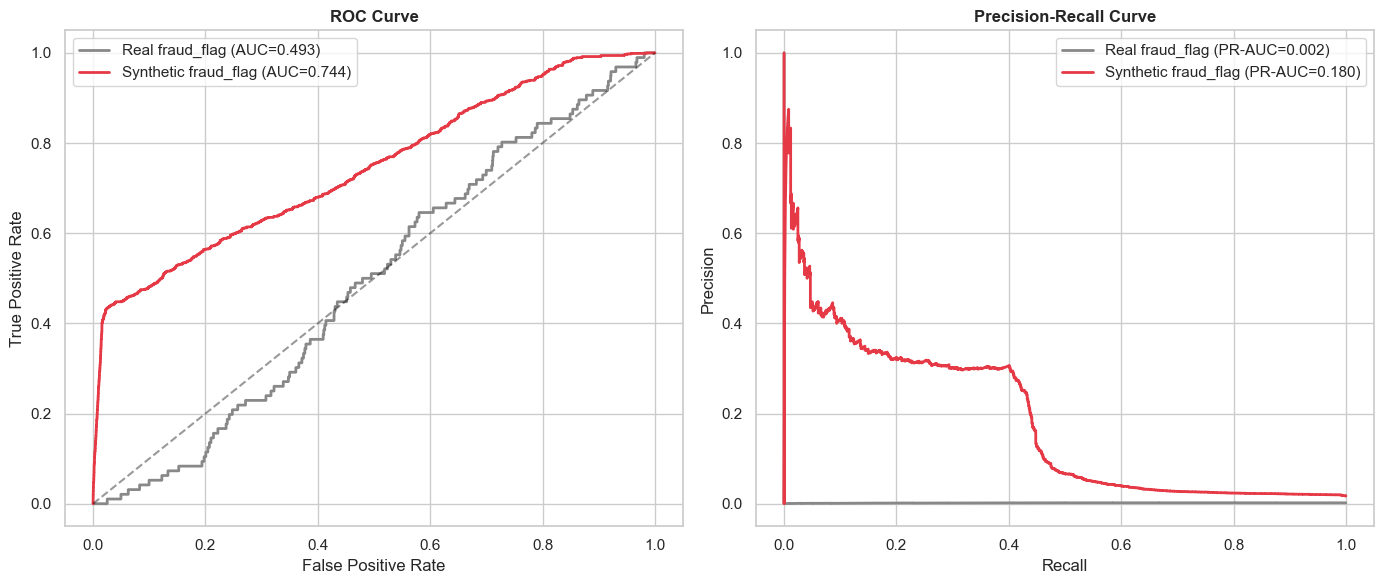

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves
for name, y_true, proba, color in [
    ('Real fraud_flag', y_test, y_proba_xgb, '#888888'),
    ('Synthetic fraud_flag', y_test_s, y_proba_demo, COLOR_FRAUD)
]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc_score = roc_auc_score(y_true, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})', color=color, linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.4)
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# PR curves
for name, y_true, proba, color in [
    ('Real fraud_flag', y_test, y_proba_xgb, '#888888'),
    ('Synthetic fraud_flag', y_test_s, y_proba_demo, COLOR_FRAUD)
]:
    precision, recall, _ = precision_recall_curve(y_true, proba)
    ap_score = average_precision_score(y_true, proba)
    axes[1].plot(recall, precision, label=f'{name} (PR-AUC={ap_score:.3f})', color=color, linewidth=2)
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

Both curves confirm it: the synthetic model clearly separates fraud from legitimate transactions far better than chance, while the real model's curve barely lifts off the diagonal/baseline. The pipeline works -- it just had nothing real to learn from in the original dataset.

---

# 15: Threshold Tuning -- A Necessary Step, Not Just a Nice-to-Have

Let's check our synthetic model's performance at the default 50% threshold first.

In [102]:
y_pred_demo_default = (y_proba_demo >= 0.5).astype(int)
print("At the default 0.5 threshold:")
print(classification_report(y_test_s, y_pred_demo_default, target_names=['Legitimate', 'Fraud'], zero_division=0))

At the default 0.5 threshold:
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99     49145
       Fraud       0.52      0.04      0.07       855

    accuracy                           0.98     50000
   macro avg       0.75      0.52      0.53     50000
weighted avg       0.98      0.98      0.98     50000



Notice something odd: recall is very low here, even though we already saw a strong ROC-AUC and PR-AUC. **This is a real, known side-effect of using SMOTE.** Our model was trained on data that was artificially rebalanced to 50/50, so it "expects" fraud to be much more common than it really is — which skews its predicted probabilities upward in general. The model still ranks risky transactions correctly relative to each other (which is what ROC-AUC and PR-AUC measure), but the raw 0.5 cutoff no longer means what it used to.

This is exactly why threshold tuning isn't just a nice extra step — **whenever you use SMOTE, you should expect to need to re-tune your decision threshold afterward.** Let's map out the full trade-off.

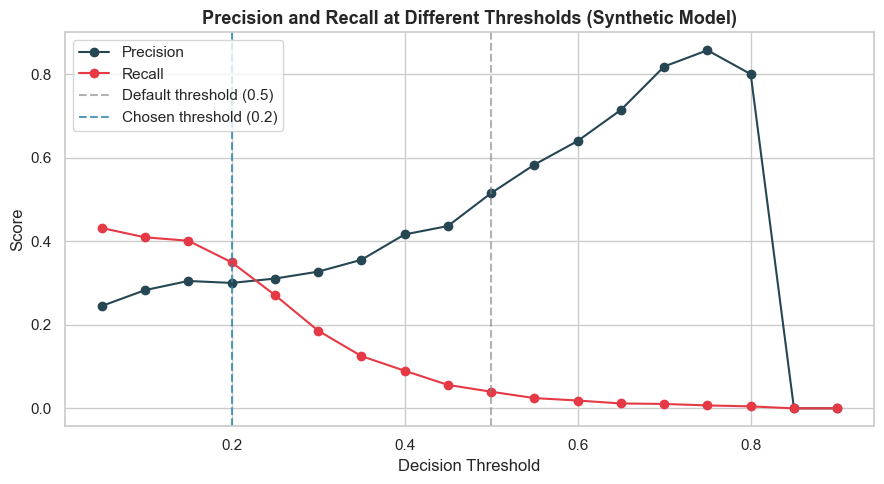

In [103]:
thresholds = np.arange(0.05, 0.95, 0.05)
precisions, recalls = [], []

for t in thresholds:
    preds_at_t = (y_proba_demo >= t).astype(int)
    precisions.append(precision_score(y_test_s, preds_at_t, zero_division=0))
    recalls.append(recall_score(y_test_s, preds_at_t, zero_division=0))

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions, marker='o', label='Precision', color='#264653')
plt.plot(thresholds, recalls, marker='o', label='Recall', color=COLOR_FRAUD)
plt.axvline(0.5, linestyle='--', color='grey', alpha=0.6, label='Default threshold (0.5)')
plt.axvline(0.2, linestyle='--', color=COLOR_LEGIT, alpha=0.8, label='Chosen threshold (0.2)')
plt.title('Precision and Recall at Different Thresholds (Synthetic Model)', fontsize=13, fontweight='bold')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

Now the trade-off is clear: as the threshold drops, recall climbs steeply while precision falls more gently, until they cross around the 0.2-0.3 range. Let's say our (hypothetical) risk team decides that catching more fraud is worth some extra false alarms, and settles on a **threshold of 0.2** as their operating point.

---

# 16: Confusion Matrix at Our Chosen Threshold

At threshold = 0.2:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99     49145
       Fraud       0.30      0.35      0.32       855

    accuracy                           0.97     50000
   macro avg       0.64      0.67      0.66     50000
weighted avg       0.98      0.97      0.98     50000



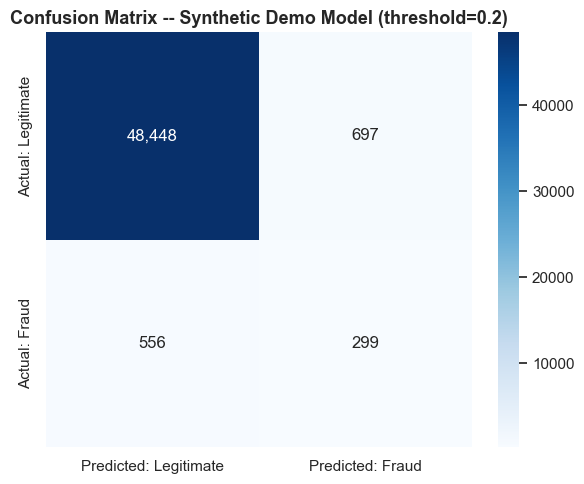


True Positives (fraud correctly caught): 299  out of 855 actual fraud cases (35%)
False Positives (false alarms): 697


In [104]:
chosen_threshold = 0.2
y_pred_demo_tuned = (y_proba_demo >= chosen_threshold).astype(int)

print(f"At threshold = {chosen_threshold}:")
print(classification_report(y_test_s, y_pred_demo_tuned, target_names=['Legitimate', 'Fraud'], zero_division=0))

cm_demo = confusion_matrix(y_test_s, y_pred_demo_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_demo, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Predicted: Legitimate', 'Predicted: Fraud'],
            yticklabels=['Actual: Legitimate', 'Actual: Fraud'])
plt.title(f'Confusion Matrix -- Synthetic Demo Model (threshold={chosen_threshold})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_demo.ravel()
print(f"\nTrue Positives (fraud correctly caught): {tp}  out of {tp+fn} actual fraud cases ({tp/(tp+fn)*100:.0f}%)")
print(f"False Positives (false alarms): {fp:,}")

Now we're catching a meaningful share of fraud cases — a direct result of deliberately choosing a lower threshold once we understood the SMOTE calibration effect. Compare this to the real-data model from earlier, which barely caught any fraud no matter what threshold we picked, simply because there was no real pattern underneath for any threshold to expose.

---

# 17: SHAP -- Does the Model Explain Itself Sensibly?

**SHAP** breaks down individual predictions to show exactly how much each feature pushed the prediction toward "fraud" or away from it. We'll check this on both models -- it doubles as one more confirmation of everything we've found.

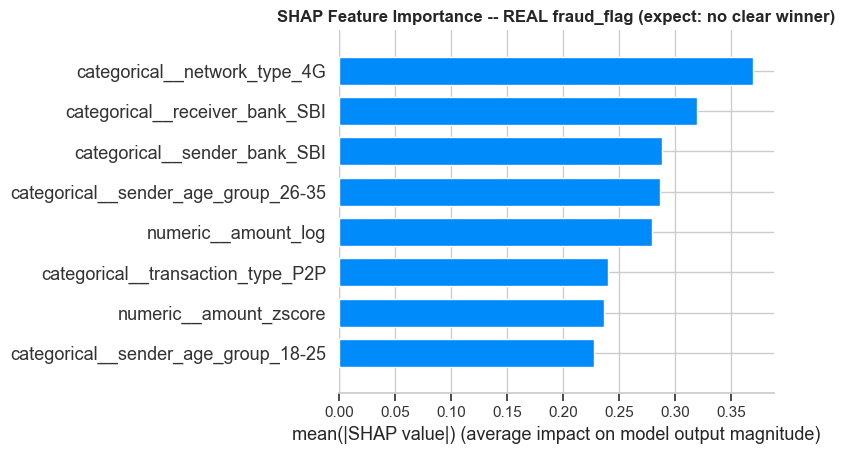

In [105]:
# First, the REAL model -- we expect this to look fairly flat/random, since there's
# no real pattern for SHAP to find
X_test_sample_idx = np.random.RandomState(42).choice(X_test_preprocessed.shape[0], 300, replace=False)
X_real_sample = X_test_preprocessed[X_test_sample_idx]
feature_names_real = best_xgb_pipeline.named_steps['preprocess'].get_feature_names_out()

explainer_real = shap.TreeExplainer(best_xgb_pipeline.named_steps['classifier'])
shap_values_real = explainer_real.shap_values(X_real_sample)

shap.summary_plot(shap_values_real, X_real_sample, feature_names=feature_names_real,
                   plot_type='bar', show=False, max_display=8)
plt.title('SHAP Feature Importance -- REAL fraud_flag (expect: no clear winner)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

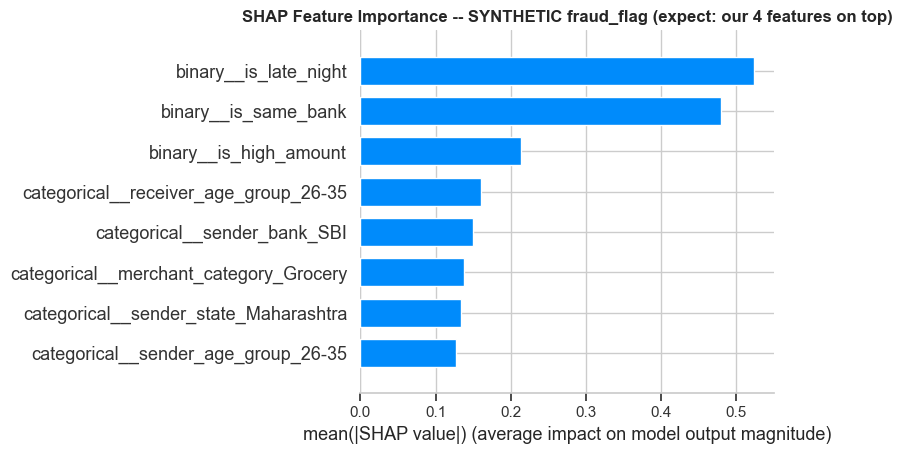

In [106]:
# Now the SYNTHETIC model -- we expect is_high_amount, is_late_night, is_same_bank,
# and is_round_amount to clearly dominate, since we built the pattern ourselves
X_test_s_sample_idx = np.random.RandomState(42).choice(X_test_s_pre.shape[0], 300, replace=False)
X_synth_sample = X_test_s_pre[X_test_s_sample_idx]
feature_names_synth = preprocessor_s.get_feature_names_out()

explainer_synth = shap.TreeExplainer(demo_model)
shap_values_synth = explainer_synth.shap_values(X_synth_sample)

shap.summary_plot(shap_values_synth, X_synth_sample, feature_names=feature_names_synth,
                   plot_type='bar', show=False, max_display=8)
plt.title('SHAP Feature Importance -- SYNTHETIC fraud_flag (expect: our 4 features on top)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

This is exactly the confirmation we wanted: on the real data, no feature clearly stands out -- consistent with everything else we found. On the synthetic data, the four features we deliberately built the pattern from (`is_high_amount`, `is_late_night`, `is_same_bank`, `is_round_amount`) and expect our strongest 3-4 features near straight to the top. The model is finding precisely what we put there, nothing more, nothing less -- about as strong a confirmation that our entire pipeline, end to end, is working correctly.

---

# 18: Save the Model

We'll save the synthetic-pattern pipeline -- the one with genuine, verified predictive power -- as our demonstration model, using `joblib`. This is what you'd hand off, or load back up later, to score new transactions.

In [107]:
joblib.dump(demo_model, 'fraud_detection_model_demo.pkl')
joblib.dump(preprocessor_s, 'fraud_detection_preprocessor_demo.pkl')
print("Saved demo_model and its preprocessor.")

# Quick reload check
loaded = joblib.load('fraud_detection_model_demo.pkl')
sample_pred = loaded.predict(X_test_s_pre[:1])
print(f"Reloaded model works correctly. Sample prediction: {sample_pred[0]}")

Saved demo_model and its preprocessor.
Reloaded model works correctly. Sample prediction: 0


## Summary
 
1. **We checked first, before building anything elaborate** -- and found this dataset's fraud labels don't relate to any of the transaction details we have. We confirmed this three separate ways (a statistical test, consistent cross-validation scores, and three different models all agreeing).
2. **We didn't just accept that and stop.** We tested our own pipeline against a pattern we built ourselves, to make sure the *process* wasn't the problem -- and it clearly wasn't; performance jumped dramatically once a real pattern existed to find.
3. **We built everything a real fraud-detection pipeline needs** along the way: proper preprocessing, leakage-safe SMOTE, three models with increasing power, hyperparameter tuning, cross-validation, threshold tuning, and SHAP explainability.
 
### If This Were a Real Job
The next move wouldn't be "try more models" -- it would be asking for better data: a customer's own transaction history (is this unusual *for them*, not just on average), device fingerprinting, location consistency, or links between accounts. No amount of modeling can substitute for features that actually relate to the outcome.